Hybrid model ready.
Depth selected: 3.0 km
Points at this depth: 24


/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


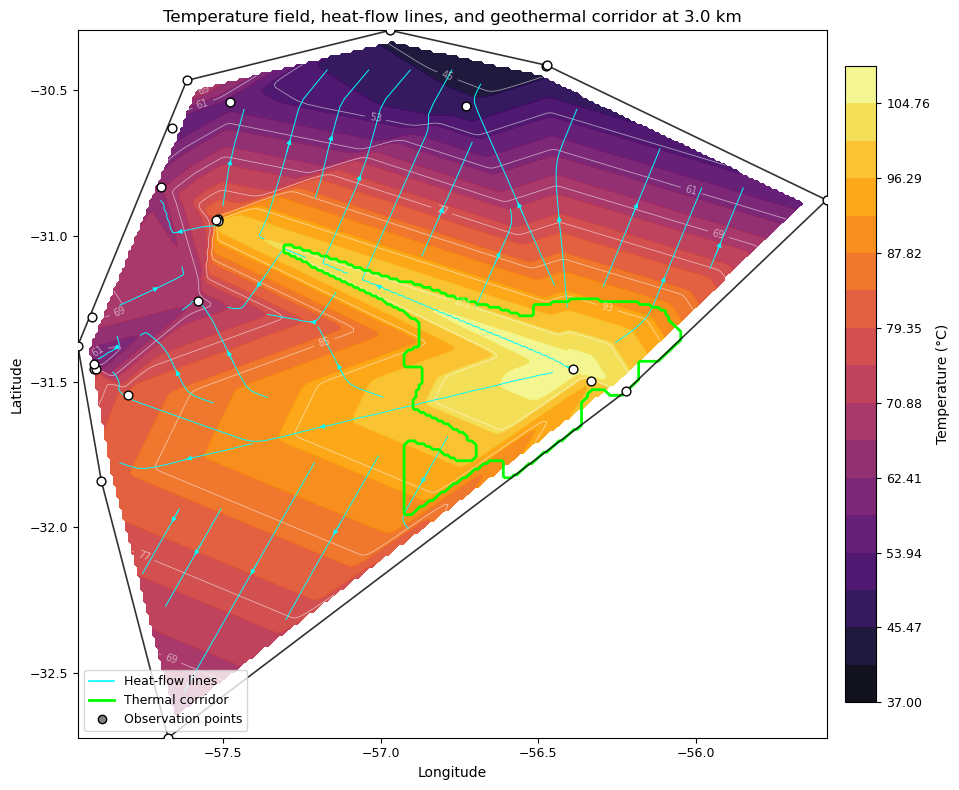

In [1]:
# Depth-specific geothermal map
# Temperature + heat-flow lines + geothermal corridor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter, binary_opening, binary_closing
from scipy.spatial import ConvexHull
from matplotlib.path import Path
from matplotlib.lines import Line2D

df_ml = pd.read_csv("data_processed/df_ml_clean.csv")
df_ml = df_ml.copy()
df_ml['grad_T'] = df_ml['Temp_obs'] / df_ml['Depth_km']
df_ml['H_physics'] = df_ml['Cond'] * df_ml['grad_T']

feature_cols_hybrid = ['Lat','Long','Depth_km','Temp_obs','Cond','grad_T','H_physics']

X_hybrid = df_ml[feature_cols_hybrid].values
y_hybrid = df_ml['Hflow'].values
rf_hybrid = RandomForestRegressor(random_state=42)
rf_hybrid.fit(X_hybrid, y_hybrid)
print("Hybrid model ready.")

depth_fixed = 3.0
grid_res = 250
sigma_temp = 0.8
sigma_cond = 0.8
sigma_hflow = 0.8
corridor_percentile = 88

plt.rcParams.update({'font.size':10,'axes.titlesize':12,'axes.labelsize':10,'xtick.labelsize':9,'ytick.labelsize':9,'legend.fontsize':9})

df_depth = df_ml[np.isclose(df_ml['Depth_km'], depth_fixed)].copy()
if df_depth.empty: raise ValueError(f"No data found for depth {depth_fixed} km")
print(f"Depth selected: {depth_fixed} km")
print(f"Points at this depth: {len(df_depth)}")

lon_min, lon_max = df_depth['Long'].min(), df_depth['Long'].max()
lat_min, lat_max = df_depth['Lat'].min(), df_depth['Lat'].max()
lon_grid = np.linspace(lon_min, lon_max, grid_res)
lat_grid = np.linspace(lat_min, lat_max, grid_res)
LON, LAT = np.meshgrid(lon_grid, lat_grid)

points = np.column_stack([df_depth['Long'], df_depth['Lat']])
temp_grid = griddata(points, df_depth['Temp_obs'], (LON, LAT), method='linear')
cond_grid = griddata(points, df_depth['Cond'], (LON, LAT), method='linear')
temp_grid_near = griddata(points, df_depth['Temp_obs'], (LON, LAT), method='linear')
cond_grid_near = griddata(points, df_depth['Cond'], (LON, LAT), method='linear')
temp_grid = np.where(np.isnan(temp_grid), temp_grid_near, temp_grid)
cond_grid = np.where(np.isnan(cond_grid), cond_grid_near, cond_grid)
temp_grid = gaussian_filter(temp_grid, sigma=sigma_temp)
cond_grid = gaussian_filter(cond_grid, sigma=sigma_cond)

tmin = df_depth['Temp_obs'].min()
tmax = df_depth['Temp_obs'].max()
temp_grid = np.clip(temp_grid, tmin, tmax)

hull = ConvexHull(points)
hull_points = points[hull.vertices]
hull_path = Path(hull_points)
grid_points = np.column_stack([LON.ravel(), LAT.ravel()])
inside_mask = hull_path.contains_points(grid_points).reshape(LON.shape)
temp_grid = np.where(inside_mask, temp_grid, np.nan)
cond_grid = np.where(inside_mask, cond_grid, np.nan)

depth_grid = np.full_like(LON, depth_fixed)
grad_T_grid = temp_grid / depth_grid
H_physics_grid = cond_grid * grad_T_grid

grid_df = pd.DataFrame({'Lat':LAT.ravel(),'Long':LON.ravel(),'Depth_km':depth_grid.ravel(),
'Temp_obs':temp_grid.ravel(),'Cond':cond_grid.ravel(),'grad_T':grad_T_grid.ravel(),
'H_physics':H_physics_grid.ravel()})

valid_idx = np.isfinite(grid_df['Temp_obs']) & np.isfinite(grid_df['Cond'])
grid_df_valid = grid_df.loc[valid_idx].copy()
X_grid_valid = grid_df_valid[feature_cols_hybrid]

hflow_pred_valid = rf_hybrid.predict(X_grid_valid)
HFLOW_GRID = np.full(LON.shape, np.nan)
HFLOW_GRID.ravel()[valid_idx.values] = hflow_pred_valid
HFLOW_GRID = np.where(inside_mask, HFLOW_GRID, np.nan)

tmp = np.where(np.isnan(HFLOW_GRID), 0, HFLOW_GRID)
w = np.where(np.isnan(HFLOW_GRID), 0, 1.0)
tmp_s = gaussian_filter(tmp, sigma=sigma_hflow)
w_s = gaussian_filter(w, sigma=sigma_hflow)
HFLOW_GRID = np.divide(tmp_s, w_s, out=np.full_like(tmp_s, np.nan), where=w_s>0)
HFLOW_GRID = np.where(inside_mask, HFLOW_GRID, np.nan)

corridor_threshold = np.nanpercentile(HFLOW_GRID, corridor_percentile)
corridor_mask = HFLOW_GRID >= corridor_threshold
corridor_mask = np.where(np.isnan(HFLOW_GRID), False, corridor_mask)
corridor_mask = binary_opening(corridor_mask, structure=np.ones((3,3)))
corridor_mask = binary_closing(corridor_mask, structure=np.ones((5,5)))
corridor_mask = corridor_mask & inside_mask

lat_mean = np.mean(lat_grid)
m_per_deg_lat = 111320.0
m_per_deg_lon = 111320.0 * np.cos(np.deg2rad(lat_mean))
dx = (lon_grid[1]-lon_grid[0])*m_per_deg_lon
dy = (lat_grid[1]-lat_grid[0])*m_per_deg_lat
dT_dy, dT_dx = np.gradient(temp_grid, dy, dx)
qx = -cond_grid*dT_dx
qy = -cond_grid*dT_dy
qx = np.where(inside_mask, qx, np.nan)
qy = np.where(inside_mask, qy, np.nan)


fig, ax = plt.subplots(figsize=(10,8))
cf = ax.contourf(LON, LAT, temp_grid, levels=np.linspace(tmin,tmax,18), cmap='inferno', alpha=0.94)
ct = ax.contour(LON, LAT, temp_grid, levels=np.linspace(tmin,tmax,10), colors='white', linewidths=0.6, alpha=0.55)
ax.clabel(ct, inline=True, fontsize=7, fmt='%.0f')

ax.streamplot(lon_grid, lat_grid, np.ma.masked_invalid(qx), np.ma.masked_invalid(qy), color='cyan', density=0.65, linewidth=0.7, arrowsize=0.7)
ax.contour(LON, LAT, corridor_mask.astype(float), levels=[0.5], colors='lime', linewidths=2.0)
ax.scatter(df_depth['Long'], df_depth['Lat'], c='white', edgecolor='black', s=40, zorder=5)
ax.plot(np.r_[hull_points[:,0],hull_points[0,0]], np.r_[hull_points[:,1],hull_points[0,1]], color='black', linewidth=1.2, alpha=0.8)

legend_elements = [Line2D([0],[0], color='cyan', lw=1.2, label='Heat-flow lines'),
Line2D([0],[0], color='lime', lw=2.0, label='Thermal corridor'),
Line2D([0],[0], marker='o', color='w', markerfacecolor='gray', markeredgecolor='black', markersize=6, label='Observation points')]

ax.legend(handles=legend_elements, loc='lower left', frameon=True)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Temperature field, heat-flow lines, and geothermal corridor at {depth_fixed:.1f} km')

cbar = fig.colorbar(cf, ax=ax, shrink=0.9, pad=0.02)
cbar.set_label('Temperature (°C)')

plt.tight_layout()
plt.savefig(f"results_depth_{depth_fixed:.1f}km_temperature_hflow_corridor.png", dpi=600, bbox_inches='tight')
plt.show()

/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


<bound method Colorbar.set_label of <matplotlib.colorbar.Colorbar object at 0x7b3cfd8dd100>>

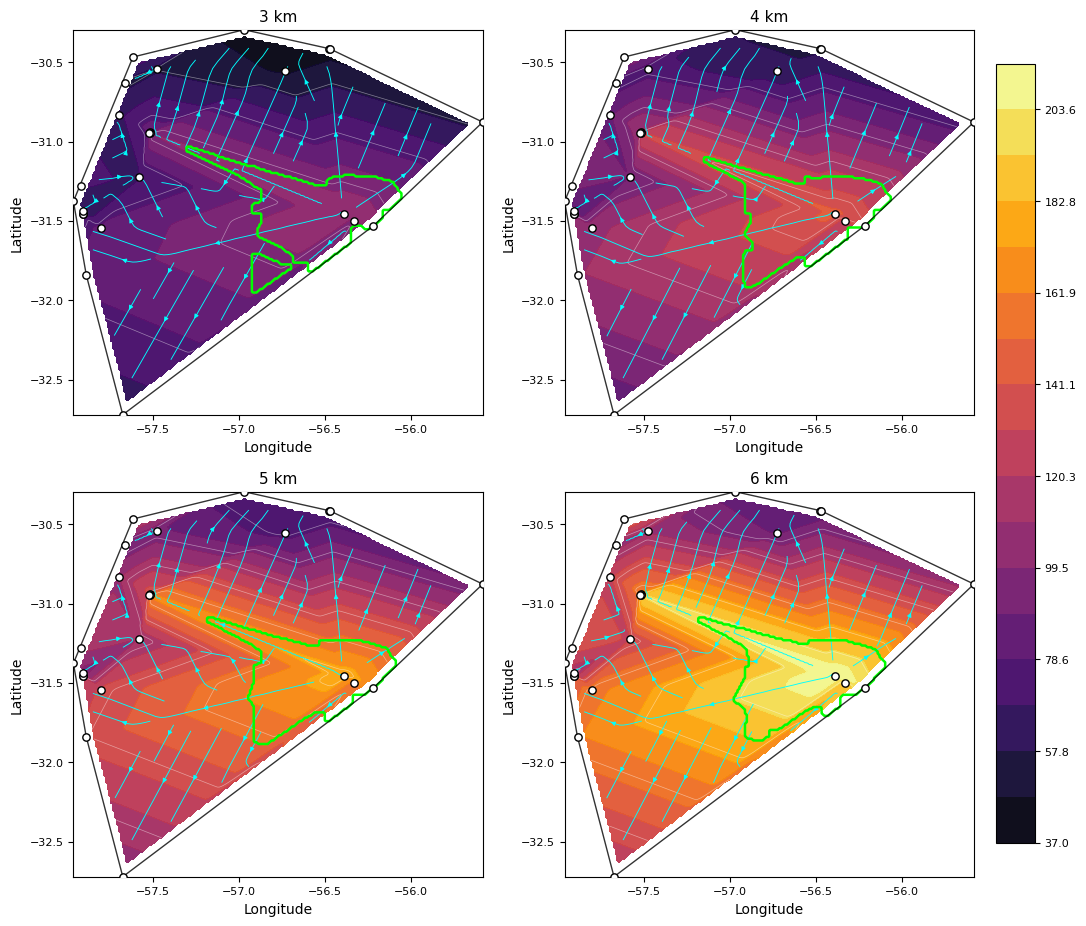

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter, binary_opening, binary_closing
from scipy.spatial import ConvexHull
from matplotlib.path import Path

# Load data

df_ml = pd.read_csv("data_processed/df_ml_clean.csv")


# Hybrid features

df_ml = df_ml.copy()
df_ml['grad_T'] = df_ml['Temp_obs'] / df_ml['Depth_km']
df_ml['H_physics'] = df_ml['Cond'] * df_ml['grad_T']

feature_cols_hybrid = [
    'Lat',
    'Long',
    'Depth_km',
    'Temp_obs',
    'Cond',
    'grad_T',
    'H_physics'
]

# Train Final Hybrid model

X_hybrid = df_ml[feature_cols_hybrid].values
y_hybrid = df_ml['Hflow'].values

rf_hybrid = RandomForestRegressor(random_state=42)
rf_hybrid.fit(X_hybrid, y_hybrid)

# Configuration

depth_list = [3.0, 4.0, 5.0, 6.0]
grid_res = 220
sigma_temp = 0.8
sigma_cond = 0.8
sigma_hflow = 0.8
corridor_percentile = 88

plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8
})

# Global temperature scale

global_tmin = df_ml['Temp_obs'].min()
global_tmax = df_ml['Temp_obs'].max()

# Figure

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.ravel()

last_cf = None

for ax, depth_fixed in zip(axes, depth_list):


    # Filter data by depth
    
    df_depth = df_ml[np.isclose(df_ml['Depth_km'], depth_fixed)].copy()

    if df_depth.empty:
        ax.set_visible(False)
        continue

    # Grid
    
    lon_min, lon_max = df_depth['Long'].min(), df_depth['Long'].max()
    lat_min, lat_max = df_depth['Lat'].min(), df_depth['Lat'].max()

    lon_grid = np.linspace(lon_min, lon_max, grid_res)
    lat_grid = np.linspace(lat_min, lat_max, grid_res)
    LON, LAT = np.meshgrid(lon_grid, lat_grid)

    # Interpolation for depth
    
    points = np.column_stack([df_depth['Long'], df_depth['Lat']])

    temp_grid = griddata(points, df_depth['Temp_obs'], (LON, LAT), method='linear')
    cond_grid = griddata(points, df_depth['Cond'], (LON, LAT), method='linear')

    temp_grid_near = griddata(points, df_depth['Temp_obs'], (LON, LAT), method='cubic')
    cond_grid_near = griddata(points, df_depth['Cond'], (LON, LAT), method='cubic')

    temp_grid = np.where(np.isnan(temp_grid), temp_grid_near, temp_grid)
    cond_grid = np.where(np.isnan(cond_grid), cond_grid_near, cond_grid)

    temp_grid = gaussian_filter(temp_grid, sigma=sigma_temp)
    cond_grid = gaussian_filter(cond_grid, sigma=sigma_cond)

    temp_grid = np.clip(temp_grid, global_tmin, global_tmax)

    # Valid domain mask
 
    hull = ConvexHull(points)
    hull_points = points[hull.vertices]
    hull_path = Path(hull_points)

    grid_points = np.column_stack([LON.ravel(), LAT.ravel()])
    inside_mask = hull_path.contains_points(grid_points).reshape(LON.shape)

    temp_grid = np.where(inside_mask, temp_grid, np.nan)
    cond_grid = np.where(inside_mask, cond_grid, np.nan)

    # Hybrid model prediction
    
    depth_grid = np.full_like(LON, depth_fixed)
    grad_T_grid = temp_grid / depth_grid
    H_physics_grid = cond_grid * grad_T_grid

    grid_df = pd.DataFrame({
        'Lat': LAT.ravel(),
        'Long': LON.ravel(),
        'Depth_km': depth_grid.ravel(),
        'Temp_obs': temp_grid.ravel(),
        'Cond': cond_grid.ravel(),
        'grad_T': grad_T_grid.ravel(),
        'H_physics': H_physics_grid.ravel()
    })

    valid_idx = np.isfinite(grid_df['Temp_obs']) & np.isfinite(grid_df['Cond'])
    grid_df_valid = grid_df.loc[valid_idx].copy()
    X_grid_valid = grid_df_valid[feature_cols_hybrid]

    hflow_pred_valid = rf_hybrid.predict(X_grid_valid)

    HFLOW_GRID = np.full(LON.shape, np.nan)
    HFLOW_GRID.ravel()[valid_idx.values] = hflow_pred_valid
    HFLOW_GRID = np.where(inside_mask, HFLOW_GRID, np.nan)

    tmp = np.where(np.isnan(HFLOW_GRID), 0, HFLOW_GRID)
    w = np.where(np.isnan(HFLOW_GRID), 0, 1.0)

    tmp_s = gaussian_filter(tmp, sigma=sigma_hflow)
    w_s = gaussian_filter(w, sigma=sigma_hflow)

    HFLOW_GRID = np.divide(tmp_s, w_s, out=np.full_like(tmp_s, np.nan), where=w_s > 0)
    HFLOW_GRID = np.where(inside_mask, HFLOW_GRID, np.nan)

    # Corridor
    
    corridor_threshold = np.nanpercentile(HFLOW_GRID, corridor_percentile)
    corridor_mask = HFLOW_GRID >= corridor_threshold
    corridor_mask = np.where(np.isnan(HFLOW_GRID), False, corridor_mask)

    corridor_mask = binary_opening(corridor_mask, structure=np.ones((3, 3)))
    corridor_mask = binary_closing(corridor_mask, structure=np.ones((5, 5)))
    corridor_mask = corridor_mask & inside_mask

    # Heat-flow lines
    
    lat_mean = np.mean(lat_grid)

    m_per_deg_lat = 111320.0
    m_per_deg_lon = 111320.0 * np.cos(np.deg2rad(lat_mean))

    dx = (lon_grid[1] - lon_grid[0]) * m_per_deg_lon
    dy = (lat_grid[1] - lat_grid[0]) * m_per_deg_lat

    dT_dy, dT_dx = np.gradient(temp_grid, dy, dx)

    qx = -cond_grid * dT_dx
    qy = -cond_grid * dT_dy

    qx = np.where(inside_mask, qx, np.nan)
    qy = np.where(inside_mask, qy, np.nan)

    # Plot
    
    last_cf = ax.contourf(
        LON, LAT, temp_grid,
        levels=np.linspace(global_tmin, global_tmax, 18),
        cmap='inferno',
        vmin=global_tmin,
        vmax=global_tmax,
        alpha=0.95
    )

    ax.contour(
        LON, LAT, temp_grid,
        levels=np.linspace(global_tmin, global_tmax, 10),
        colors='white',
        linewidths=0.5,
        alpha=0.45
    )

    ax.streamplot(
        lon_grid, lat_grid,
        np.ma.masked_invalid(qx),
        np.ma.masked_invalid(qy),
        color='cyan',
        density=0.75,
        linewidth=0.65,
        arrowsize=0.65
    )

    ax.contour(
        LON, LAT,
        corridor_mask.astype(float),
        levels=[0.5],
        colors='lime',
        linewidths=1.8
    )

    ax.scatter(
        df_depth['Long'], df_depth['Lat'],
        c='white',
        edgecolor='black',
        s=28,
        zorder=5
    )

    ax.plot(
        np.r_[hull_points[:, 0], hull_points[0, 0]],
        np.r_[hull_points[:, 1], hull_points[0, 1]],
        color='black',
        linewidth=1.0,
        alpha=0.8
    )

    ax.set_title(f'{depth_fixed:.0f} km')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

# Shared Colorbar

cbar = fig.colorbar(last_cf, ax=axes, shrink=0.92, pad=0.02)
cbar.set_label

Original hybrid Hflow model trained.

Summary indices:
  Index     Value
0   SCI  0.201533
1   PCI  0.798467
2   SPR  0.252400


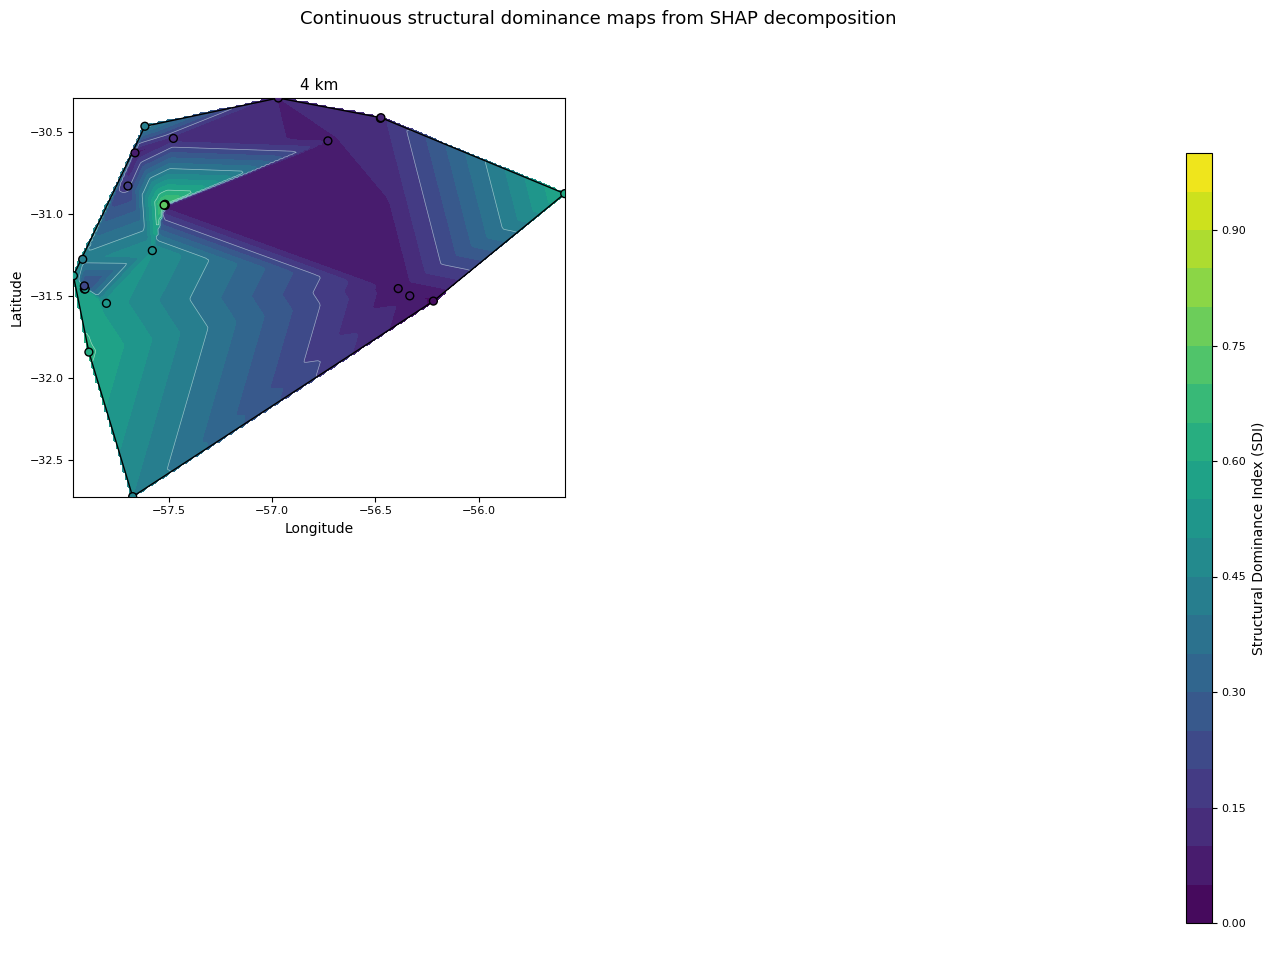

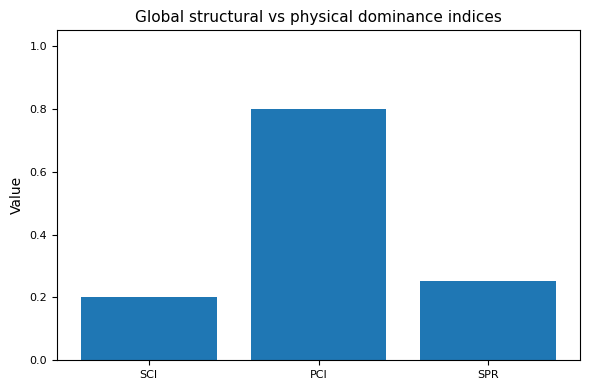

In [3]:
# Structural dominance analysis
# Original hybrid Hflow model + SHAP

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.ensemble import RandomForestRegressor
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
from scipy.spatial import ConvexHull
from matplotlib.path import Path

# Load data

df_ml = pd.read_csv("data_processed/df_ml_clean.csv").copy()

required_cols = ['Lat', 'Long', 'Depth_km', 'Temp_obs', 'Cond', 'Hflow']
missing = [c for c in required_cols if c not in df_ml.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")


# Build original hybrid model features

df_h = df_ml.copy()
df_h['grad_T'] = df_h['Temp_obs'] / df_h['Depth_km']
df_h['H_physics'] = df_h['Cond'] * df_h['grad_T']

feature_cols_hybrid = [
    'Lat',
    'Long',
    'Depth_km',
    'Temp_obs',
    'Cond',
    'grad_T',
    'H_physics'
]

X = df_h[feature_cols_hybrid].copy()
y = df_h['Hflow'].copy()

# Train original hybrid model

rf_hybrid = RandomForestRegressor(
    n_estimators=400,
    random_state=42,
    n_jobs=-1
)
rf_hybrid.fit(X, y)
print("Original hybrid Hflow model trained.")

# SHAP values

explainer = shap.TreeExplainer(rf_hybrid)
shap_values = explainer.shap_values(X)

if isinstance(shap_values, list):
    shap_values = shap_values[0]

shap_df = pd.DataFrame(shap_values, columns=feature_cols_hybrid)

# Absolute SHAP

abs_shap_df = shap_df.abs()

# Define spatial vs physical groups

spatial_cols = ['Lat', 'Long']
physical_cols = ['Temp_obs', 'Cond', 'grad_T', 'H_physics']

spatial_shap_sum = abs_shap_df[spatial_cols].sum().sum()
physical_shap_sum = abs_shap_df[physical_cols].sum().sum()

SCI = spatial_shap_sum / (spatial_shap_sum + physical_shap_sum + 1e-12)
PCI = physical_shap_sum / (spatial_shap_sum + physical_shap_sum + 1e-12)
SPR = spatial_shap_sum / (physical_shap_sum + 1e-12)

summary_indices = pd.DataFrame({
    'Index': ['SCI', 'PCI', 'SPR'],
    'Value': [SCI, PCI, SPR]
})

print("\nSummary indices:")
print(summary_indices)

# optional save
summary_indices.to_csv("summary_structural_indices.csv", index=False)


# Local structural dominance index (SDI)

eps = 1e-12

df_h['spatial_shap_sum'] = abs_shap_df['Lat'] + abs_shap_df['Long']
df_h['physical_shap_sum'] = abs_shap_df[physical_cols].sum(axis=1)
df_h['total_shap_sum'] = abs_shap_df[feature_cols_hybrid].sum(axis=1)

df_h['SDI'] = df_h['spatial_shap_sum'] / (df_h['total_shap_sum'] + eps)
df_h['PDI'] = df_h['physical_shap_sum'] / (df_h['total_shap_sum'] + eps)
df_h['SD_minus_PD'] = df_h['spatial_shap_sum'] - df_h['physical_shap_sum']

# save point table
df_h[['Lat', 'Long', 'Depth_km', 'Hflow', 'SDI', 'PDI', 'SD_minus_PD']].to_csv(
    "pointwise_structural_dominance_indices.csv",
    index=False
)

# Helper function for safe smoothing

def smooth_masked(arr, sigma=0.5):
    if sigma <= 0:
        return arr.copy()
    mask = np.isfinite(arr).astype(float)
    arr0 = np.where(np.isfinite(arr), arr, 0.0)
    arr_s = gaussian_filter(arr0, sigma=sigma)
    mask_s = gaussian_filter(mask, sigma=sigma)
    out = np.divide(
        arr_s,
        mask_s,
        out=np.full_like(arr_s, np.nan),
        where=mask_s > 1e-6
    )
    out[mask_s < 0.05] = np.nan
    return out

# Common grid

depth_list = [4.0]
grid_res = 220
sigma_sdi = 0.45

lon_min, lon_max = df_h['Long'].min(), df_h['Long'].max()
lat_min, lat_max = df_h['Lat'].min(), df_h['Lat'].max()

lon_grid = np.linspace(lon_min, lon_max, grid_res)
lat_grid = np.linspace(lat_min, lat_max, grid_res)

LON, LAT = np.meshgrid(lon_grid, lat_grid)
grid_points_lonlat = np.column_stack([LON.ravel(), LAT.ravel()])

# Build SDI maps by depth 

depth_results = []

for depth_fixed in depth_list:
    df_depth = df_h[np.isclose(df_h['Depth_km'], depth_fixed)].copy()
    if df_depth.empty:
        continue

    points_depth = np.column_stack([df_depth['Long'], df_depth['Lat']])
    if len(points_depth) < 3:
        continue

    hull = ConvexHull(points_depth)
    hull_points = points_depth[hull.vertices]
    hull_path = Path(hull_points)
    inside_mask = hull_path.contains_points(grid_points_lonlat).reshape(LON.shape)

    sdi_grid = griddata(points_depth, df_depth['SDI'], (LON, LAT), method='linear')
    sdi_grid_near = griddata(points_depth, df_depth['SDI'], (LON, LAT), method='nearest')
    sdi_grid = np.where(np.isnan(sdi_grid), sdi_grid_near, sdi_grid)
    sdi_grid = np.where(inside_mask, sdi_grid, np.nan)
    sdi_grid = smooth_masked(sdi_grid, sigma=sigma_sdi)

    depth_results.append({
        'depth': depth_fixed,
        'df_depth': df_depth,
        'hull_points': hull_points,
        'inside_mask': inside_mask,
        'SDI_GRID': sdi_grid
    })


# Plot 2x2 SDI Map

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.ravel()
last_cf = None

for ax, result in zip(axes, depth_results):
    depth_fixed = result['depth']
    df_depth = result['df_depth']
    hull_points = result['hull_points']
    sdi_grid = result['SDI_GRID']

    last_cf = ax.contourf(
        LON, LAT, sdi_grid,
        levels=np.linspace(0, 1, 21),
        cmap='viridis',
        vmin=0,
        vmax=1
    )

    ax.contour(
        LON, LAT, sdi_grid,
        levels=np.linspace(0, 1, 6),
        colors='white',
        linewidths=0.5,
        alpha=0.5
    )

    ax.scatter(
        df_depth['Long'], df_depth['Lat'],
        c=df_depth['SDI'],
        cmap='viridis',
        vmin=0,
        vmax=1,
        edgecolor='black',
        s=32,
        zorder=5
    )

    ax.plot(
        np.r_[hull_points[:, 0], hull_points[0, 0]],
        np.r_[hull_points[:, 1], hull_points[0, 1]],
        color='black',
        linewidth=1.0
    )

    ax.set_title(f'{depth_fixed:.0f} km')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

# Turn off unused axes if needed
for j in range(len(depth_results), 4):
    axes[j].axis('off')

cax = fig.add_axes([0.92, 0.15, 0.018, 0.70])
cbar = fig.colorbar(last_cf, cax=cax)
cbar.set_label('Structural Dominance Index (SDI)')

fig.suptitle(
    'Continuous structural dominance maps from SHAP decomposition',
    fontsize=13,
    y=0.98
)

plt.subplots_adjust(top=0.90, right=0.89, wspace=0.18, hspace=0.18)
plt.savefig("structural_dominance_index_maps_2x2.png", dpi=600, bbox_inches='tight')
plt.show()

# Bar plot of global index

plt.figure(figsize=(6, 4))
plt.bar(summary_indices['Index'], summary_indices['Value'])
plt.ylabel('Value')
plt.title('Global structural vs physical dominance indices')
plt.ylim(0, max(1.05, summary_indices['Value'].max() * 1.15))
plt.tight_layout()
plt.savefig("summary_structural_indices_barplot.png", dpi=600, bbox_inches='tight')
plt.show()


================ RANDOM CV ABLATION ================

              Model  RMSE_mean  RMSE_std  MAE_mean  R2_mean  \
0       Full hybrid     3.2214    0.5080    2.6285   0.9763   
1    No coordinates     5.2730    1.4553    4.2971   0.9354   
2  Coordinates only     7.9301    1.6482    6.3222   0.8616   

   Delta_RMSE_vs_full  
0              0.0000  
1              2.0516  
2              4.7087  

Wilcoxon paired test (RMSE fold-by-fold):
No coordinates vs Full hybrid -> statistic=15.0, p=0.031250
Coordinates only vs Full hybrid -> statistic=15.0, p=0.031250

================ SPATIAL BLOCK DEFINITION ================

Latitude block size : 0.35
Longitude block size: 0.35
Unique spatial blocks: 14

================ SPATIAL BLOCK CV ABLATION ================

              Model  RMSE_mean  RMSE_std  MAE_mean  R2_mean  \
0       Full hybrid    10.4531    4.5956    8.8028   0.3187   
1    No coordinates     9.9383    3.6165    8.1421   0.2733   
2  Coordinates only    22.0880   12.823

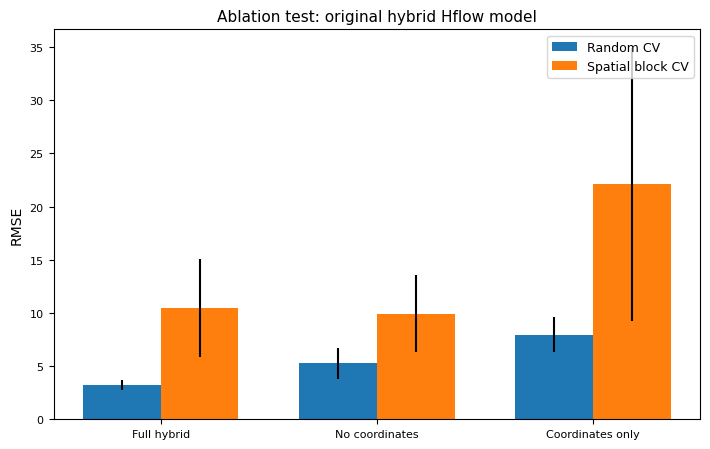

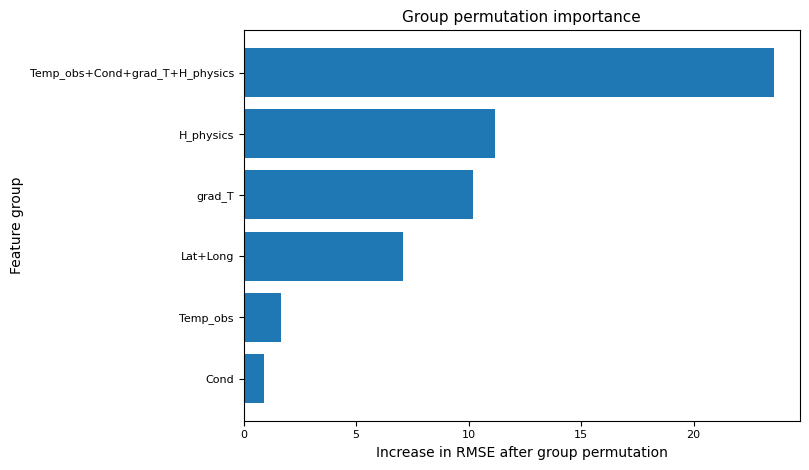

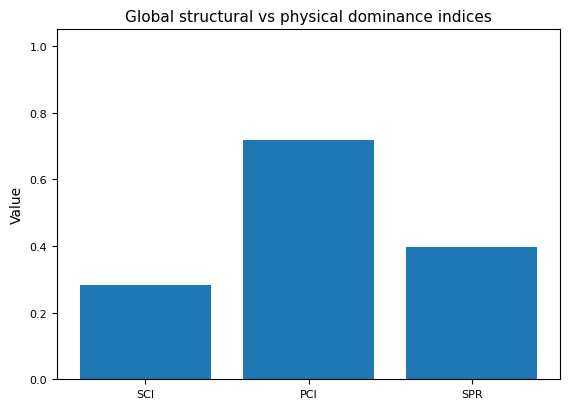

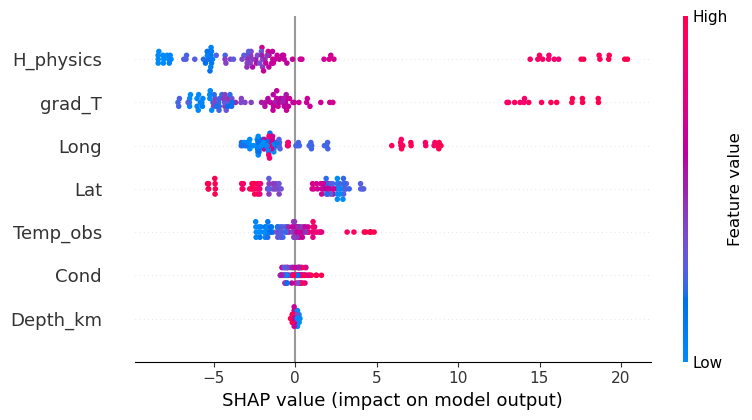

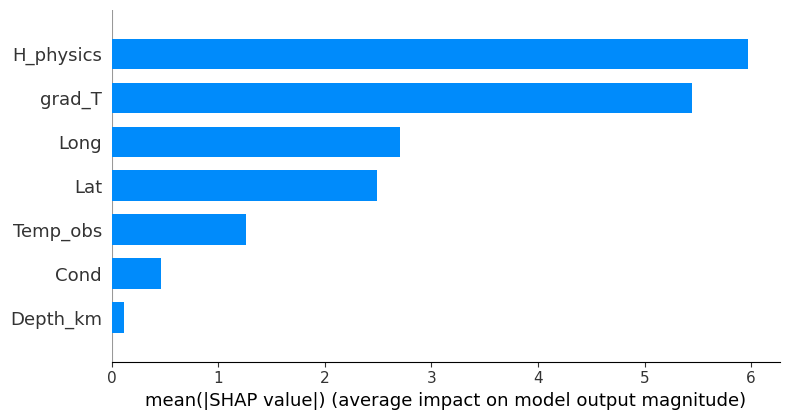


================ FILES SAVED ================
ablation_random_cv_hflow.csv
ablation_spatial_block_cv_hflow.csv
group_permutation_importance_hflow.csv
feature_permutation_importance_hflow.csv
summary_structural_indices_hflow.csv
local_sdi_values_hflow.csv


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from scipy.stats import wilcoxon

df = df_ml.copy()

required_cols = ['Lat', 'Long', 'Depth_km', 'Temp_obs', 'Cond', 'Hflow']
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in df_ml: {missing_cols}")

# Build the original hybrid physics features

df['grad_T'] = df['Temp_obs'] / df['Depth_km']
df['H_physics'] = df['Cond'] * df['grad_T']

df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=[
    'Lat', 'Long', 'Depth_km', 'Temp_obs',
    'Cond', 'grad_T', 'H_physics', 'Hflow'
]).reset_index(drop=True)

# Define feature sets

features_full = ['Lat', 'Long', 'Depth_km', 'Temp_obs', 'Cond', 'grad_T', 'H_physics']
features_no_coords = ['Depth_km', 'Temp_obs', 'Cond', 'grad_T', 'H_physics']
features_coords_only = ['Lat', 'Long', 'Depth_km']

target_col = 'Hflow'

X_full = df[features_full].copy()
X_no_coords = df[features_no_coords].copy()
X_coords_only = df[features_coords_only].copy()
y = df[target_col].values

# Random Forest Model Settings

rf_params = dict(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

# Metric Function

def compute_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

# Generic Evaluation

def evaluate_model_cv(X, y, splitter, groups=None, model_params=None):

    if model_params is None:
        model_params = rf_params

    rmses, maes, r2s = [], [], []
    fold_predictions = []

    if groups is None and hasattr(splitter, 'split'):
        split_iterator = splitter.split(X, y)
    elif groups is not None and hasattr(splitter, 'split'):
        split_iterator = splitter.split(X, y, groups)
    else:
        split_iterator = splitter

    for fold_id, (tr_idx, te_idx) in enumerate(split_iterator, start=1):
        model = RandomForestRegressor(**model_params)
        model.fit(X.iloc[tr_idx], y[tr_idx])

        pred = model.predict(X.iloc[te_idx])
        rmse, mae, r2 = compute_metrics(y[te_idx], pred)

        rmses.append(rmse)
        maes.append(mae)
        r2s.append(r2)

        fold_predictions.append(pd.DataFrame({
            'fold': fold_id,
            'index': te_idx,
            'y_true': y[te_idx],
            'y_pred': pred
        }))

    pred_df = pd.concat(fold_predictions, ignore_index=True)

    return {
        'rmse': np.array(rmses),
        'mae': np.array(maes),
        'r2': np.array(r2s),
        'predictions': pred_df
    }

# Random ablation test

cv_random = KFold(n_splits=5, shuffle=True, random_state=42)

res_full_random = evaluate_model_cv(X_full, y, cv_random)
res_no_coords_random = evaluate_model_cv(X_no_coords, y, cv_random)
res_coords_only_random = evaluate_model_cv(X_coords_only, y, cv_random)

summary_random = pd.DataFrame({
    'Model': ['Full hybrid', 'No coordinates', 'Coordinates only'],
    'RMSE_mean': [
        res_full_random['rmse'].mean(),
        res_no_coords_random['rmse'].mean(),
        res_coords_only_random['rmse'].mean()
    ],
    'RMSE_std': [
        res_full_random['rmse'].std(ddof=1),
        res_no_coords_random['rmse'].std(ddof=1),
        res_coords_only_random['rmse'].std(ddof=1)
    ],
    'MAE_mean': [
        res_full_random['mae'].mean(),
        res_no_coords_random['mae'].mean(),
        res_coords_only_random['mae'].mean()
    ],
    'R2_mean': [
        res_full_random['r2'].mean(),
        res_no_coords_random['r2'].mean(),
        res_coords_only_random['r2'].mean()
    ]
})

summary_random['Delta_RMSE_vs_full'] = (
    summary_random['RMSE_mean'] - summary_random.loc[0, 'RMSE_mean']
)

print('\n================ RANDOM CV ABLATION ================\n')
print(summary_random.round(4))

# Spatial block

lat_block = 0.35
lon_block = 0.35

lat0 = df['Lat'].min()
lon0 = df['Long'].min()

lat_bin = np.floor((df['Lat'] - lat0) / lat_block).astype(int)
lon_bin = np.floor((df['Long'] - lon0) / lon_block).astype(int)

groups = (lat_bin.astype(str) + '_' + lon_bin.astype(str)).values
n_unique_groups = len(np.unique(groups))

print('\n================ SPATIAL BLOCK DEFINITION ================\n')
print(f'Latitude block size : {lat_block}')
print(f'Longitude block size: {lon_block}')
print(f'Unique spatial blocks: {n_unique_groups}')

n_splits_block = min(5, n_unique_groups)
if n_splits_block < 3:
    raise ValueError('Not enough spatial blocks.')

cv_block = GroupKFold(n_splits=n_splits_block)

res_full_block = evaluate_model_cv(X_full, y, cv_block, groups=groups)
res_no_coords_block = evaluate_model_cv(X_no_coords, y, cv_block, groups=groups)
res_coords_only_block = evaluate_model_cv(X_coords_only, y, cv_block, groups=groups)

summary_block = pd.DataFrame({
    'Model': ['Full hybrid', 'No coordinates', 'Coordinates only'],
    'RMSE_mean': [
        res_full_block['rmse'].mean(),
        res_no_coords_block['rmse'].mean(),
        res_coords_only_block['rmse'].mean()
    ],
    'RMSE_std': [
        res_full_block['rmse'].std(ddof=1),
        res_no_coords_block['rmse'].std(ddof=1),
        res_coords_only_block['rmse'].std(ddof=1)
    ],
    'MAE_mean': [
        res_full_block['mae'].mean(),
        res_no_coords_block['mae'].mean(),
        res_coords_only_block['mae'].mean()
    ],
    'R2_mean': [
        res_full_block['r2'].mean(),
        res_no_coords_block['r2'].mean(),
        res_coords_only_block['r2'].mean()
    ]
})

summary_block['Delta_RMSE_vs_full'] = (
    summary_block['RMSE_mean'] - summary_block.loc[0, 'RMSE_mean']
)

print('\n================ SPATIAL BLOCK CV ABLATION ================\n')
print(summary_block.round(4))

# Final Model

rf_full = RandomForestRegressor(**rf_params)
rf_full.fit(X_full, y)
y_pred_full = rf_full.predict(X_full)

rmse_all, mae_all, r2_all = compute_metrics(y, y_pred_full)

print('\n================ FINAL MODEL ================\n')
print(f'RMSE = {rmse_all:.4f}')
print(f'MAE = {mae_all:.4f}')
print(f'R2 = {r2_all:.4f}')

# Group permutation importance

def group_permutation_importance(model, X, y, group_cols, n_repeats=100, random_state=42):
    rng = np.random.RandomState(random_state)

    base_pred = model.predict(X)
    base_rmse = np.sqrt(mean_squared_error(y, base_pred))

    permuted_rmses = []

    for _ in range(n_repeats):
        X_perm = X.copy()
        perm_idx = rng.permutation(len(X_perm))

        for col in group_cols:
            X_perm[col] = X_perm[col].values[perm_idx]

        pred_perm = model.predict(X_perm)
        rmse_perm = np.sqrt(mean_squared_error(y, pred_perm))
        permuted_rmses.append(rmse_perm)

    permuted_rmses = np.array(permuted_rmses)

    return {
        'group': '+'.join(group_cols),
        'base_rmse': base_rmse,
        'rmse_perm_mean': permuted_rmses.mean(),
        'rmse_perm_std': permuted_rmses.std(ddof=1),
        'delta_rmse': permuted_rmses.mean() - base_rmse
    }

group_results = []
group_results.append(group_permutation_importance(rf_full, X_full, y, ['Lat', 'Long']))
group_results.append(group_permutation_importance(rf_full, X_full, y, ['Temp_obs', 'Cond', 'grad_T', 'H_physics']))
group_results.append(group_permutation_importance(rf_full, X_full, y, ['H_physics']))
group_results.append(group_permutation_importance(rf_full, X_full, y, ['grad_T']))
group_results.append(group_permutation_importance(rf_full, X_full, y, ['Temp_obs']))
group_results.append(group_permutation_importance(rf_full, X_full, y, ['Cond']))

group_perm_df = pd.DataFrame(group_results)\
    .sort_values('delta_rmse', ascending=False)\
    .reset_index(drop=True)

print('\n================ GROUP PERMUTATION IMPORTANCE ================\n')
print(group_perm_df.round(4))

# Standard permutation importance

perm = permutation_importance(
    rf_full,
    X_full,
    y,
    n_repeats=100,
    random_state=42,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'Feature': X_full.columns,
    'Importance_mean': perm.importances_mean,
    'Importance_std': perm.importances_std
}).sort_values('Importance_mean', ascending=False).reset_index(drop=True)

print('\n================ FEATURE PERMUTATION IMPORTANCE ================\n')
print(perm_df.round(4))

# SHAP global group dominance

explainer = shap.TreeExplainer(rf_full)
shap_values = explainer.shap_values(X_full)

if isinstance(shap_values, list):
    shap_values = shap_values[0]

abs_shap = np.abs(shap_values)
abs_shap_df = pd.DataFrame(abs_shap, columns=X_full.columns)

spatial_cols = ['Lat', 'Long']
physical_cols = ['Temp_obs', 'Cond', 'grad_T', 'H_physics']

spatial_shap_sum = abs_shap_df[spatial_cols].sum().sum()
physical_shap_sum = abs_shap_df[physical_cols].sum().sum()

SCI = spatial_shap_sum / (spatial_shap_sum + physical_shap_sum + 1e-12)
PCI = physical_shap_sum / (spatial_shap_sum + physical_shap_sum + 1e-12)
SPR = spatial_shap_sum / (physical_shap_sum + 1e-12)

summary_indices = pd.DataFrame({
    'Index': ['SCI', 'PCI', 'SPR'],
    'Value': [SCI, PCI, SPR]
})

print('\n================ SHAP GROUP DOMINANCE INDICES ================\n')
print(summary_indices.round(6))

# Local SDI
df_sdi = df.copy()
df_sdi['pred_Hflow'] = y_pred_full
df_sdi['spatial_shap'] = abs_shap_df[spatial_cols].sum(axis=1)
df_sdi['physical_shap'] = abs_shap_df[physical_cols].sum(axis=1)
df_sdi['total_shap'] = abs_shap_df.sum(axis=1)
df_sdi['SDI'] = df_sdi['spatial_shap'] / (df_sdi['total_shap'] + 1e-12)

# Plots

# Ablation RMSE
fig, ax = plt.subplots(figsize=(7.2, 4.6))
x = np.arange(len(summary_random))

ax.bar(
    x - 0.18,
    summary_random['RMSE_mean'],
    width=0.36,
    yerr=summary_random['RMSE_std'],
    label='Random CV'
)

ax.bar(
    x + 0.18,
    summary_block['RMSE_mean'],
    width=0.36,
    yerr=summary_block['RMSE_std'],
    label='Spatial block CV'
)

ax.set_xticks(x)
ax.set_xticklabels(summary_random['Model'])
ax.set_ylabel('RMSE')
ax.set_title('Ablation test: original hybrid Hflow model')
ax.legend(frameon=True)

plt.tight_layout()
plt.show()

# Group permutation importance
fig, ax = plt.subplots(figsize=(8.2, 4.8))
ax.barh(group_perm_df['group'], group_perm_df['delta_rmse'])

ax.set_xlabel('Increase in RMSE after group permutation')
ax.set_ylabel('Feature group')
ax.set_title('Group permutation importance')

ax.invert_yaxis()

plt.tight_layout()
plt.show()

# SHAP index
fig, ax = plt.subplots(figsize=(5.8, 4.2))
ax.bar(summary_indices['Index'], summary_indices['Value'])

ax.set_ylabel('Value')
ax.set_title('Global structural vs physical dominance indices')
ax.set_ylim(0, max(1.05, summary_indices['Value'].max() * 1.15))

plt.tight_layout()
plt.show()

# SHAP beeswarm
shap.summary_plot(shap_values, X_full, show=False)
plt.tight_layout()
plt.show()

# SHAP bar
shap.summary_plot(shap_values, X_full, plot_type='bar', show=False)
plt.tight_layout()
plt.show()

# Export files

summary_random.to_csv('ablation_random_cv_hflow.csv', index=False)
summary_block.to_csv('ablation_spatial_block_cv_hflow.csv', index=False)
group_perm_df.to_csv('group_permutation_importance_hflow.csv', index=False)
perm_df.to_csv('feature_permutation_importance_hflow.csv', index=False)
summary_indices.to_csv('summary_structural_indices_hflow.csv', index=False)
df_sdi.to_csv('local_sdi_values_hflow.csv', index=False)

print('\n================ FILES SAVED ================')
print('ablation_random_cv_hflow.csv')
print('ablation_spatial_block_cv_hflow.csv')
print('group_permutation_importance_hflow.csv')
print('feature_permutation_importance_hflow.csv')
print('summary_structural_indices_hflow.csv')
print('local_sdi_values_hflow.csv')

========== GLOBAL SECTION SCALES ==========
Temperature scale : 48.42 to 212.30
Hflow scale : 49.45 to 128.17


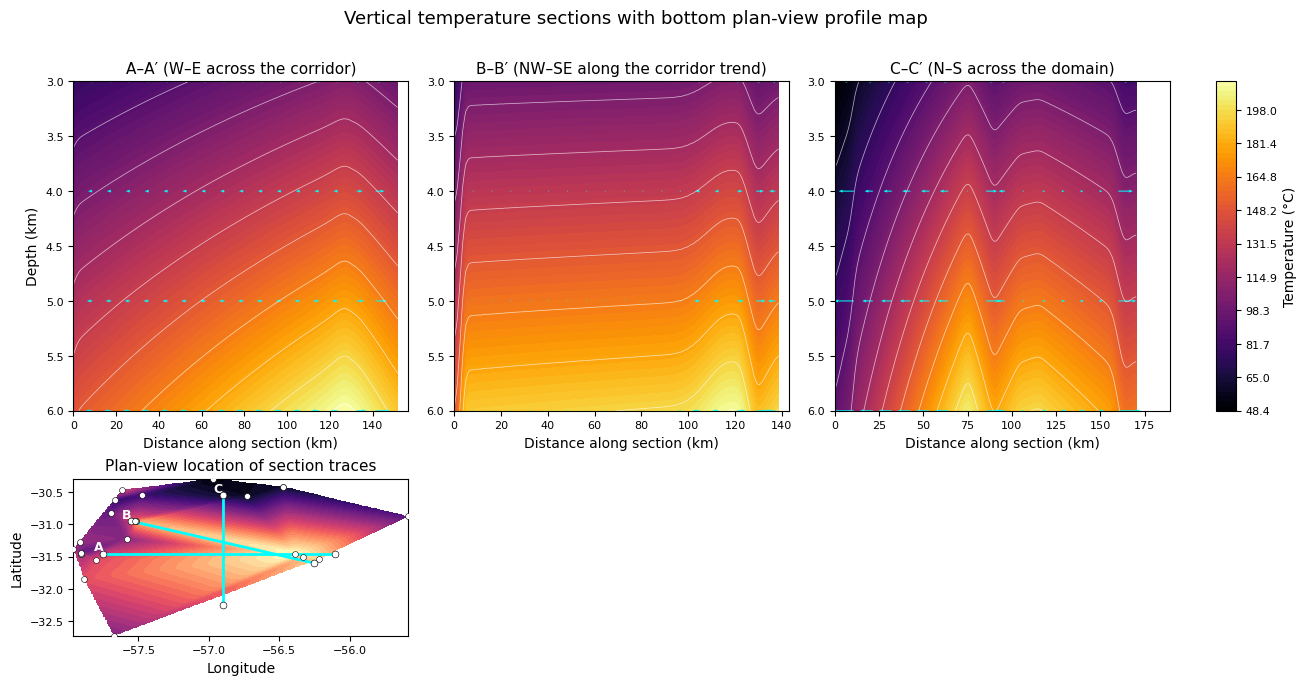

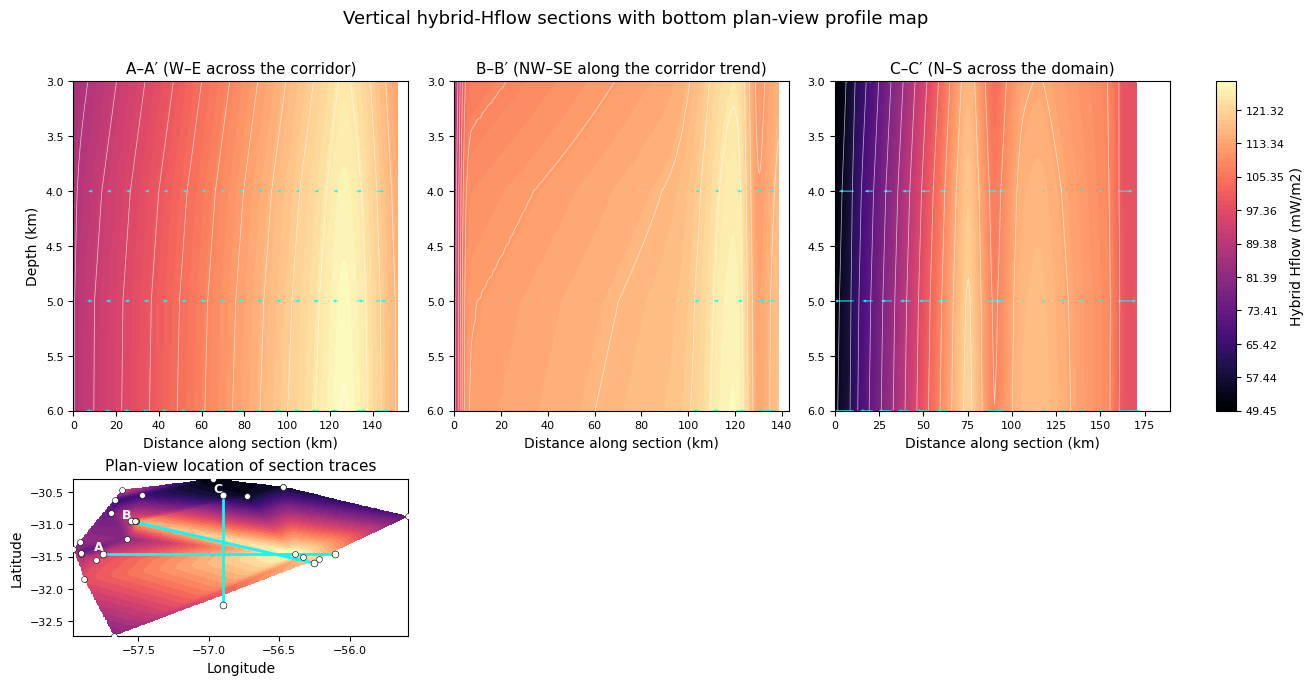

In [13]:
# Vertical Sections

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
from scipy.spatial import ConvexHull
from matplotlib.path import Path
from matplotlib.gridspec import GridSpec

# Helpers

def smooth_masked(arr, mask, sigma=1.5):
    mask_float = mask.astype(float)
    arr_filled = np.where(mask, arr, 0.0)
    smooth = gaussian_filter(arr_filled, sigma=sigma)
    weight = gaussian_filter(mask_float, sigma=sigma)
    out = np.full_like(arr, np.nan, dtype=float)
    valid = weight > 1e-12
    out[valid] = smooth[valid] / weight[valid]
    out[~mask] = np.nan
    return out

def build_depth_fields(depth_fixed, sigma_temp=1.2, sigma_cond=1.0, sigma_hflow=0.8):
    df_depth = df_ml[np.isclose(df_ml['Depth_km'], depth_fixed)].copy()
    if df_depth.empty:
        raise ValueError(f'No data found for depth {depth_fixed} km')

    points_depth = df_depth[['Long', 'Lat']].values
    hull = ConvexHull(points_depth)
    hull_points = points_depth[hull.vertices]
    hull_path = Path(hull_points)
    grid_points = np.c_[LON.ravel(), LAT.ravel()]
    inside_mask_depth = hull_path.contains_points(grid_points, radius=1e-6).reshape(LON.shape)

    # Temperature
    TEMP_GRID = griddata(points_depth, df_depth['Temp_obs'].values, (LON, LAT), method='linear')
    TEMP_GRID_near = griddata(points_depth, df_depth['Temp_obs'].values, (LON, LAT), method='nearest')
    TEMP_GRID = np.where(np.isnan(TEMP_GRID), TEMP_GRID_near, TEMP_GRID)
    TEMP_GRID = np.where(inside_mask_depth, TEMP_GRID, np.nan)
    TEMP_GRID = smooth_masked(TEMP_GRID, inside_mask_depth, sigma=sigma_temp)

    # Conductivity
    COND_GRID = griddata(points_depth, df_depth['Cond'].values, (LON, LAT), method='linear')
    COND_GRID_near = griddata(points_depth, df_depth['Cond'].values, (LON, LAT), method='nearest')
    COND_GRID = np.where(np.isnan(COND_GRID), COND_GRID_near, COND_GRID)
    COND_GRID = np.where(inside_mask_depth, COND_GRID, np.nan)
    COND_GRID = smooth_masked(COND_GRID, inside_mask_depth, sigma=sigma_cond)

    # Hybrid Hflow
    grad_T_grid = TEMP_GRID / depth_fixed
    HFLOW_GRID = COND_GRID * grad_T_grid
    HFLOW_GRID = np.where(inside_mask_depth, HFLOW_GRID, np.nan)
    HFLOW_GRID = smooth_masked(HFLOW_GRID, inside_mask_depth, sigma=sigma_hflow)

    # Metric spacing
    lat_mean = np.mean(lat_grid)
    m_per_deg_lat = 111320.0
    m_per_deg_lon = 111320.0 * np.cos(np.deg2rad(lat_mean))
    dx = (lon_grid[1] - lon_grid[0]) * m_per_deg_lon
    dy = (lat_grid[1] - lat_grid[0]) * m_per_deg_lat

    # Vectors
    dT_dy, dT_dx = np.gradient(TEMP_GRID, dy, dx)
    qx = -COND_GRID * dT_dx
    qy = -COND_GRID * dT_dy
    qx = np.where(inside_mask_depth, qx, np.nan)
    qy = np.where(inside_mask_depth, qy, np.nan)

    return {
        'depth': depth_fixed,
        'TEMP_GRID': TEMP_GRID,
        'COND_GRID': COND_GRID,
        'HFLOW_GRID': HFLOW_GRID,
        'qx': qx,
        'qy': qy,
        'df_depth': df_depth,
        'inside_mask_depth': inside_mask_depth,
        'hull_points': hull_points
    }

def bilinear_sample(grid, xq, yq):
    pts = np.c_[LON.ravel(), LAT.ravel()]
    vals = grid.ravel()
    return griddata(pts, vals, (xq, yq), method='linear')

def make_section(x0, y0, x1, y1, npts=320):
    xs = np.linspace(x0, x1, npts)
    ys = np.linspace(y0, y1, npts)
    lat_mean = np.mean(lat_grid)
    km_per_deg_lat = 111.32
    km_per_deg_lon = 111.32 * np.cos(np.deg2rad(lat_mean))
    dxs = np.diff(xs) * km_per_deg_lon
    dys = np.diff(ys) * km_per_deg_lat
    ds = np.sqrt(dxs**2 + dys**2)
    dist_km = np.concatenate([[0.0], np.cumsum(ds)])
    return xs, ys, dist_km


# Depth levels

depth_list = [3.0, 4.0, 5.0, 6.0]
depth_results = {d: build_depth_fields(d) for d in depth_list}


# Define sections

sections = [
    {'name': 'A–A′ (W–E across the corridor)', 'short_left': 'A', 'short_right': 'A′',
     'x0': -57.75, 'y0': -31.45, 'x1': -56.10, 'y1': -31.45},
    {'name': 'B–B′ (NW–SE along the corridor trend)', 'short_left': 'B', 'short_right': 'B′',
     'x0': -57.55, 'y0': -30.95, 'x1': -56.25, 'y1': -31.60},
    {'name': 'C–C′ (N–S across the domain)', 'short_left': 'C', 'short_right': 'C′',
     'x0': -56.90, 'y0': -30.55, 'x1': -56.90, 'y1': -32.25}
]

# Build Section matrix

section_data = []
for sec in sections:
    xs, ys, dist_km = make_section(sec['x0'], sec['y0'], sec['x1'], sec['y1'], npts=320)
    T_sec, H_sec, qx_sec, qy_sec = [], [], [], []

    for d in depth_list:
        R = depth_results[d]
        T_sec.append(bilinear_sample(R['TEMP_GRID'], xs, ys))
        H_sec.append(bilinear_sample(R['HFLOW_GRID'], xs, ys))
        qx_sec.append(bilinear_sample(R['qx'], xs, ys))
        qy_sec.append(bilinear_sample(R['qy'], xs, ys))

    T_sec = np.array(T_sec)
    H_sec = np.array(H_sec)
    qx_sec = np.array(qx_sec)
    qy_sec = np.array(qy_sec)

    lat_mean = np.mean(lat_grid)
    km_per_deg_lat = 111.32
    km_per_deg_lon = 111.32 * np.cos(np.deg2rad(lat_mean))
    dx_sec = (sec['x1'] - sec['x0']) * km_per_deg_lon
    dy_sec = (sec['y1'] - sec['y0']) * km_per_deg_lat
    norm = np.sqrt(dx_sec**2 + dy_sec**2)
    ux, uy = dx_sec / norm, dy_sec / norm
    q_along = qx_sec * ux + qy_sec * uy

    section_data.append({
        'name': sec['name'],
        'short_left': sec['short_left'],
        'short_right': sec['short_right'],
        'x0': sec['x0'], 'y0': sec['y0'],
        'x1': sec['x1'], 'y1': sec['y1'],
        'xs': xs, 'ys': ys, 'dist_km': dist_km,
        'T_sec': T_sec, 'H_sec': H_sec, 'q_along': q_along
    })


# Global Shared scales

all_T = np.concatenate([s['T_sec'][np.isfinite(s['T_sec'])] for s in section_data])
all_H = np.concatenate([s['H_sec'][np.isfinite(s['H_sec'])] for s in section_data])
T_vmin, T_vmax = np.nanmin(all_T), np.nanmax(all_T)
H_vmin, H_vmax = np.nanmin(all_H), np.nanmax(all_H)
print("========== GLOBAL SECTION SCALES ==========")
print(f"Temperature scale : {T_vmin:.2f} to {T_vmax:.2f}")
print(f"Hflow scale : {H_vmin:.2f} to {H_vmax:.2f}")

# Plan-view background for bottom mini map

Rmap = depth_results[5.0]
HMAP = Rmap['HFLOW_GRID']
HMAP_plot = smooth_masked(HMAP, np.isfinite(HMAP), sigma=1.0)

# Plotting functions

def plot_section(fig_title, field_key, cmap_name, vmin, vmax, cbar_label):
    fig = plt.figure(figsize=(15, 7.2))
    gs = GridSpec(nrows=2, ncols=4, height_ratios=[4.2, 2.0], width_ratios=[1,1,1,0.06], hspace=0.28, wspace=0.18)
    axes = [fig.add_subplot(gs[0, i]) for i in range(3)]
    cax = fig.add_subplot(gs[0, 3])
    ax_map = fig.add_subplot(gs[1, 0])
    last_cf = None

    for i, (ax, s) in enumerate(zip(axes, section_data)):
        X, Z = np.meshgrid(s['dist_km'], depth_list)
        last_cf = ax.contourf(X, Z, s[field_key], levels=np.linspace(vmin, vmax, 70), cmap=cmap_name, vmin=vmin, vmax=vmax)
        ax.contour(X, Z, s[field_key], levels=12, colors='white', linewidths=0.55, alpha=0.65)

        skip_x = 18
        Xq, Zq = X[:, ::skip_x], Z[:, ::skip_x]
        Uq = s['q_along'][:, ::skip_x]
        Udir = Uq / (np.nanmax(np.abs(Uq)) + 1e-12)
        Wdir = np.zeros_like(Udir)
        ax.quiver(Xq, Zq, Udir, Wdir, color='cyan', scale=14, width=0.003, headwidth=3.0, headlength=4.0, headaxislength=3.6)

        ax.set_ylim(max(depth_list), min(depth_list))
        ax.set_title(s['name'], fontsize=11)
        ax.set_xlabel('Distance along section (km)')
        if i == 0:
            ax.set_ylabel('Depth (km)')

    cbar = fig.colorbar(last_cf, cax=cax)
    cbar.set_label(cbar_label, fontsize=10)

    # bottom mini map
    ax_map.contourf(LON, LAT, HMAP_plot, levels=35, cmap='magma')
    for s in section_data:
        ax_map.plot([s['x0'], s['x1']], [s['y0'], s['y1']], color='cyan', linewidth=2.0)
        ax_map.scatter([s['x0'], s['x1']], [s['y0'], s['y1']], c='white', s=24, edgecolors='black', linewidths=0.45, zorder=5)
        ax_map.text(s['x0'], s['y0'], s['short_left'], color='white', fontsize=9, weight='bold', ha='right', va='bottom')
        ax_map.text(s['x1'], s['y1'], s['short_right'], color='white', fontsize=9, weight='bold', ha='left', va='top')

    ax_map.scatter(Rmap['df_depth']['Long'], Rmap['df_depth']['Lat'], c='white', s=18, edgecolors='black', linewidths=0.4, zorder=5)
    ax_map.set_title('Plan-view location of section traces', fontsize=11)
    ax_map.set_xlabel('Longitude')
    ax_map.set_ylabel('Latitude')

    fig.suptitle(fig_title, fontsize=13, y=0.98)
    plt.show()
    plt.close()

# Plot temperature sections
plot_section('Vertical temperature sections with bottom plan-view profile map', 'T_sec', 'inferno', T_vmin, T_vmax, 'Temperature (°C)')

# Plot hybrid Hflow sections
plot_section('Vertical hybrid-Hflow sections with bottom plan-view profile map', 'H_sec', 'magma', H_vmin, H_vmax, 'Hybrid Hflow (mW/m2)')

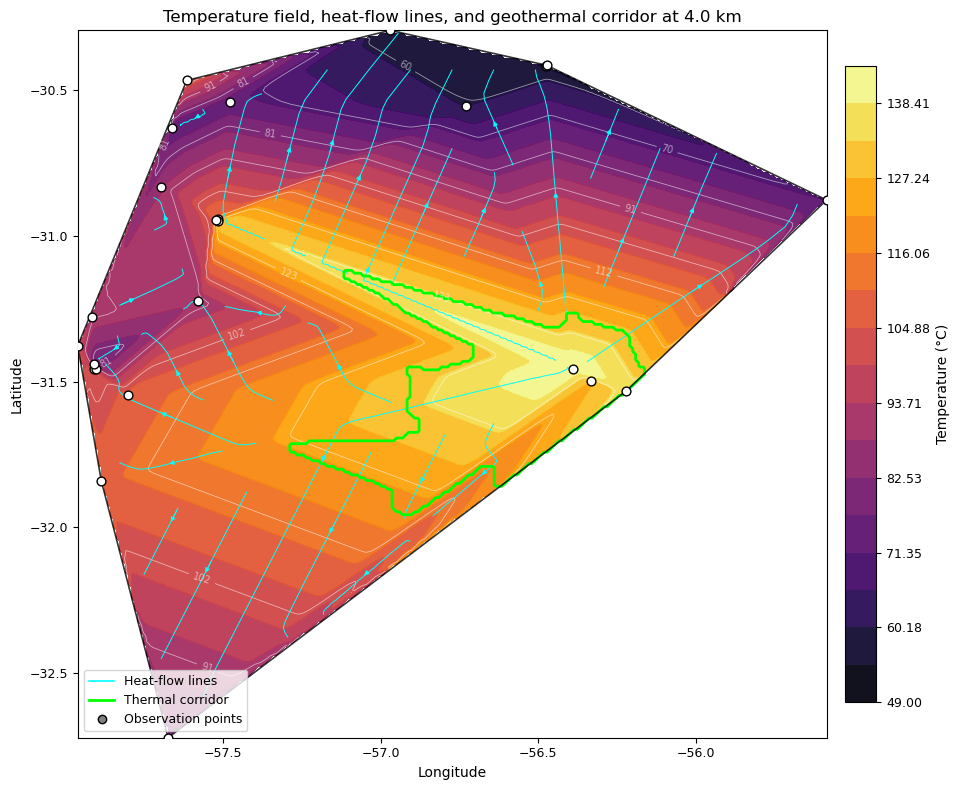

In [15]:
# Gradient Boosting hybrid model

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter, binary_opening, binary_closing
from scipy.spatial import ConvexHull
from matplotlib.path import Path
from matplotlib.lines import Line2D

df_ml = pd.read_csv("data_processed/df_ml_clean.csv")
df_ml = df_ml.copy()
df_ml['grad_T'] = df_ml['Temp_obs'] / df_ml['Depth_km']
df_ml['H_physics'] = df_ml['Cond'] * df_ml['grad_T']

feature_cols_hybrid = ['Lat', 'Long', 'Depth_km', 'Temp_obs', 'Cond', 'grad_T', 'H_physics']

X_hybrid = df_ml[feature_cols_hybrid].values
y_hybrid = df_ml['Hflow'].values

gbr_hybrid = GradientBoostingRegressor(
    random_state=42,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3
)
gbr_hybrid.fit(X_hybrid, y_hybrid)

depth_fixed = 4.0
grid_res = 250
sigma_temp = 0.8
sigma_cond = 0.8
sigma_hflow = 0.8
corridor_percentile = 88

plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9
})

df_depth = df_ml[np.isclose(df_ml['Depth_km'], depth_fixed)].copy()
if df_depth.empty:
    raise ValueError(f"No data found for depth {depth_fixed} km")

lon_min, lon_max = df_depth['Long'].min(), df_depth['Long'].max()
lat_min, lat_max = df_depth['Lat'].min(), df_depth['Lat'].max()

lon_grid = np.linspace(lon_min, lon_max, grid_res)
lat_grid = np.linspace(lat_min, lat_max, grid_res)
LON, LAT = np.meshgrid(lon_grid, lat_grid)

points = np.column_stack([df_depth['Long'], df_depth['Lat']])

temp_grid = griddata(points, df_depth['Temp_obs'], (LON, LAT), method='linear')
cond_grid = griddata(points, df_depth['Cond'], (LON, LAT), method='linear')

temp_grid_near = griddata(points, df_depth['Temp_obs'], (LON, LAT), method='nearest')
cond_grid_near = griddata(points, df_depth['Cond'], (LON, LAT), method='nearest')

temp_grid = np.where(np.isnan(temp_grid), temp_grid_near, temp_grid)
cond_grid = np.where(np.isnan(cond_grid), cond_grid_near, cond_grid)

temp_grid = gaussian_filter(temp_grid, sigma=sigma_temp)
cond_grid = gaussian_filter(cond_grid, sigma=sigma_cond)

tmin = df_depth['Temp_obs'].min()
tmax = df_depth['Temp_obs'].max()
temp_grid = np.clip(temp_grid, tmin, tmax)

hull = ConvexHull(points)
hull_points = points[hull.vertices]
hull_path = Path(hull_points)

grid_points = np.column_stack([LON.ravel(), LAT.ravel()])
inside_mask = hull_path.contains_points(grid_points).reshape(LON.shape)

temp_grid = np.where(inside_mask, temp_grid, np.nan)
cond_grid = np.where(inside_mask, cond_grid, np.nan)

depth_grid = np.full_like(LON, depth_fixed)
grad_T_grid = temp_grid / depth_grid
H_physics_grid = cond_grid * grad_T_grid

grid_df = pd.DataFrame({
    'Lat': LAT.ravel(),
    'Long': LON.ravel(),
    'Depth_km': depth_grid.ravel(),
    'Temp_obs': temp_grid.ravel(),
    'Cond': cond_grid.ravel(),
    'grad_T': grad_T_grid.ravel(),
    'H_physics': H_physics_grid.ravel()
})

valid_idx = np.isfinite(grid_df['Temp_obs']) & np.isfinite(grid_df['Cond'])
grid_df_valid = grid_df.loc[valid_idx].copy()
X_grid_valid = grid_df_valid[feature_cols_hybrid].values

hflow_pred_valid = gbr_hybrid.predict(X_grid_valid)

HFLOW_GRID = np.full(LON.shape, np.nan)
HFLOW_GRID.ravel()[valid_idx.values] = hflow_pred_valid
HFLOW_GRID = np.where(inside_mask, HFLOW_GRID, np.nan)

tmp = np.where(np.isnan(HFLOW_GRID), 0, HFLOW_GRID)
w = np.where(np.isnan(HFLOW_GRID), 0, 1.0)
tmp_s = gaussian_filter(tmp, sigma=sigma_hflow)
w_s = gaussian_filter(w, sigma=sigma_hflow)
HFLOW_GRID = np.divide(tmp_s, w_s, out=np.full_like(tmp_s, np.nan), where=w_s > 0)
HFLOW_GRID = np.where(inside_mask, HFLOW_GRID, np.nan)

corridor_threshold = np.nanpercentile(HFLOW_GRID, corridor_percentile)
corridor_mask = HFLOW_GRID >= corridor_threshold
corridor_mask = np.where(np.isnan(HFLOW_GRID), False, corridor_mask)
corridor_mask = binary_opening(corridor_mask, structure=np.ones((3, 3)))
corridor_mask = binary_closing(corridor_mask, structure=np.ones((5, 5)))
corridor_mask = corridor_mask & inside_mask

lat_mean = np.mean(lat_grid)
m_per_deg_lat = 111320.0
m_per_deg_lon = 111320.0 * np.cos(np.deg2rad(lat_mean))

dx = (lon_grid[1] - lon_grid[0]) * m_per_deg_lon
dy = (lat_grid[1] - lat_grid[0]) * m_per_deg_lat

dT_dy, dT_dx = np.gradient(temp_grid, dy, dx)
qx = -cond_grid * dT_dx
qy = -cond_grid * dT_dy

qx = np.where(inside_mask, qx, np.nan)
qy = np.where(inside_mask, qy, np.nan)

fig, ax = plt.subplots(figsize=(10, 8))

cf = ax.contourf(
    LON, LAT, temp_grid,
    levels=np.linspace(tmin, tmax, 18),
    cmap='inferno',
    alpha=0.94
)

ct = ax.contour(
    LON, LAT, temp_grid,
    levels=np.linspace(tmin, tmax, 10),
    colors='white',
    linewidths=0.6,
    alpha=0.55
)
ax.clabel(ct, inline=True, fontsize=7, fmt='%.0f')

ax.streamplot(
    lon_grid, lat_grid,
    np.ma.masked_invalid(qx),
    np.ma.masked_invalid(qy),
    color='cyan',
    density=0.65,
    linewidth=0.7,
    arrowsize=0.7
)

ax.contour(
    LON, LAT, corridor_mask.astype(float),
    levels=[0.5],
    colors='lime',
    linewidths=2.0
)

ax.scatter(
    df_depth['Long'], df_depth['Lat'],
    c='white', edgecolor='black', s=40, zorder=5
)

ax.plot(
    np.r_[hull_points[:, 0], hull_points[0, 0]],
    np.r_[hull_points[:, 1], hull_points[0, 1]],
    color='black', linewidth=1.2, alpha=0.8
)

legend_elements = [
    Line2D([0], [0], color='cyan', lw=1.2, label='Heat-flow lines'),
    Line2D([0], [0], color='lime', lw=2.0, label='Thermal corridor'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
            markeredgecolor='black', markersize=6, label='Observation points')
]

ax.legend(handles=legend_elements, loc='lower left', frameon=True)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Temperature field, heat-flow lines, and geothermal corridor at {depth_fixed:.1f} km')

cbar = fig.colorbar(cf, ax=ax, shrink=0.9, pad=0.02)
cbar.set_label('Temperature (°C)')

plt.tight_layout()
plt.savefig(
    f"results_depth_{depth_fixed:.1f}km_temperature_hflow_corridor_GBR.png",
    dpi=600,
    bbox_inches='tight'
)
plt.show()

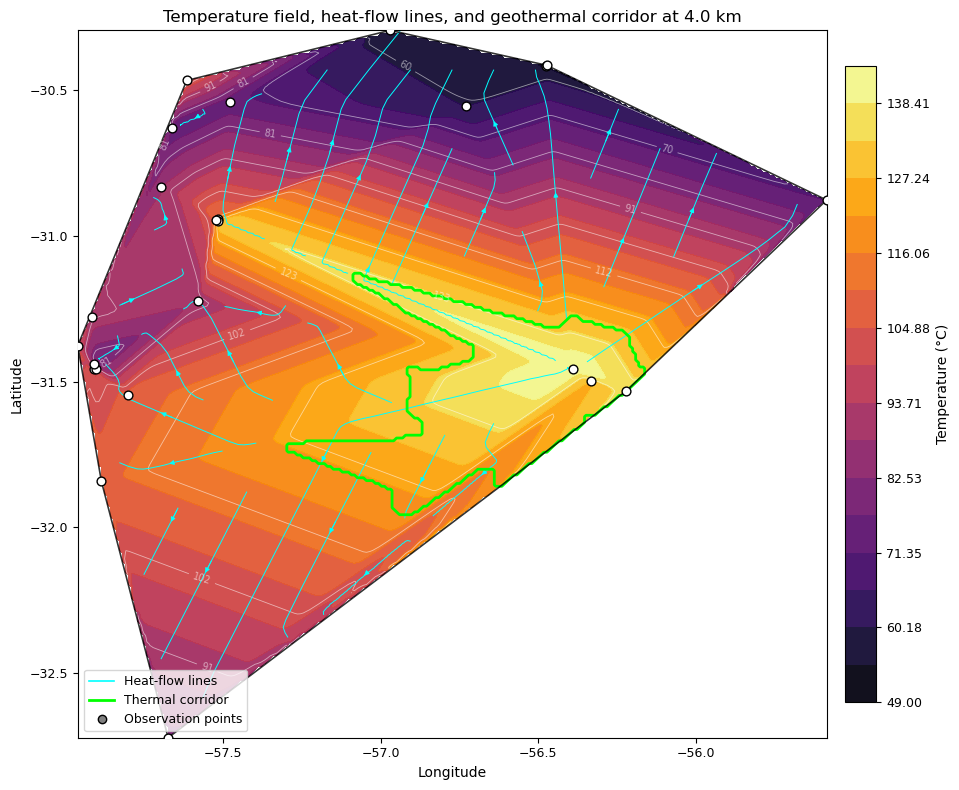

In [16]:
# Stacking model hybrid selected

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter, binary_opening, binary_closing
from scipy.spatial import ConvexHull
from matplotlib.path import Path
from matplotlib.lines import Line2D

df_ml = pd.read_csv("data_processed/df_ml_clean.csv")
df_ml = df_ml.copy()
df_ml['grad_T'] = df_ml['Temp_obs'] / df_ml['Depth_km']
df_ml['H_physics'] = df_ml['Cond'] * df_ml['grad_T']

feature_cols_hybrid = ['Lat', 'Long', 'Depth_km', 'Temp_obs', 'Cond', 'grad_T', 'H_physics']

X_hybrid = df_ml[feature_cols_hybrid].values
y_hybrid = df_ml['Hflow'].values

estimators = [
    ('rf', RandomForestRegressor(random_state=42, n_estimators=300)),
    ('gbr', GradientBoostingRegressor(random_state=42, n_estimators=300, learning_rate=0.05, max_depth=3))
]

stack_hybrid = StackingRegressor(
    estimators=estimators,
    final_estimator=LinearRegression(),
    cv=5,
    passthrough=False
)

stack_hybrid.fit(X_hybrid, y_hybrid)

depth_fixed = 4.0
grid_res = 250
sigma_temp = 0.8
sigma_cond = 0.8
sigma_hflow = 0.8
corridor_percentile = 88

plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9
})

df_depth = df_ml[np.isclose(df_ml['Depth_km'], depth_fixed)].copy()
if df_depth.empty:
    raise ValueError(f"No data found for depth {depth_fixed} km")

lon_min, lon_max = df_depth['Long'].min(), df_depth['Long'].max()
lat_min, lat_max = df_depth['Lat'].min(), df_depth['Lat'].max()

lon_grid = np.linspace(lon_min, lon_max, grid_res)
lat_grid = np.linspace(lat_min, lat_max, grid_res)
LON, LAT = np.meshgrid(lon_grid, lat_grid)

points = np.column_stack([df_depth['Long'], df_depth['Lat']])

temp_grid = griddata(points, df_depth['Temp_obs'], (LON, LAT), method='linear')
cond_grid = griddata(points, df_depth['Cond'], (LON, LAT), method='linear')

temp_grid_near = griddata(points, df_depth['Temp_obs'], (LON, LAT), method='nearest')
cond_grid_near = griddata(points, df_depth['Cond'], (LON, LAT), method='nearest')

temp_grid = np.where(np.isnan(temp_grid), temp_grid_near, temp_grid)
cond_grid = np.where(np.isnan(cond_grid), cond_grid_near, cond_grid)

temp_grid = gaussian_filter(temp_grid, sigma=sigma_temp)
cond_grid = gaussian_filter(cond_grid, sigma=sigma_cond)

tmin = df_depth['Temp_obs'].min()
tmax = df_depth['Temp_obs'].max()
temp_grid = np.clip(temp_grid, tmin, tmax)

hull = ConvexHull(points)
hull_points = points[hull.vertices]
hull_path = Path(hull_points)

grid_points = np.column_stack([LON.ravel(), LAT.ravel()])
inside_mask = hull_path.contains_points(grid_points).reshape(LON.shape)

temp_grid = np.where(inside_mask, temp_grid, np.nan)
cond_grid = np.where(inside_mask, cond_grid, np.nan)

depth_grid = np.full_like(LON, depth_fixed)
grad_T_grid = temp_grid / depth_grid
H_physics_grid = cond_grid * grad_T_grid

grid_df = pd.DataFrame({
    'Lat': LAT.ravel(),
    'Long': LON.ravel(),
    'Depth_km': depth_grid.ravel(),
    'Temp_obs': temp_grid.ravel(),
    'Cond': cond_grid.ravel(),
    'grad_T': grad_T_grid.ravel(),
    'H_physics': H_physics_grid.ravel()
})

valid_idx = np.isfinite(grid_df['Temp_obs']) & np.isfinite(grid_df['Cond'])
grid_df_valid = grid_df.loc[valid_idx].copy()
X_grid_valid = grid_df_valid[feature_cols_hybrid].values

hflow_pred_valid = stack_hybrid.predict(X_grid_valid)

HFLOW_GRID = np.full(LON.shape, np.nan)
HFLOW_GRID.ravel()[valid_idx.values] = hflow_pred_valid
HFLOW_GRID = np.where(inside_mask, HFLOW_GRID, np.nan)

tmp = np.where(np.isnan(HFLOW_GRID), 0, HFLOW_GRID)
w = np.where(np.isnan(HFLOW_GRID), 0, 1.0)
tmp_s = gaussian_filter(tmp, sigma=sigma_hflow)
w_s = gaussian_filter(w, sigma=sigma_hflow)
HFLOW_GRID = np.divide(tmp_s, w_s, out=np.full_like(tmp_s, np.nan), where=w_s > 0)
HFLOW_GRID = np.where(inside_mask, HFLOW_GRID, np.nan)

corridor_threshold = np.nanpercentile(HFLOW_GRID, corridor_percentile)
corridor_mask = HFLOW_GRID >= corridor_threshold
corridor_mask = np.where(np.isnan(HFLOW_GRID), False, corridor_mask)
corridor_mask = binary_opening(corridor_mask, structure=np.ones((3, 3)))
corridor_mask = binary_closing(corridor_mask, structure=np.ones((5, 5)))
corridor_mask = corridor_mask & inside_mask

lat_mean = np.mean(lat_grid)
m_per_deg_lat = 111320.0
m_per_deg_lon = 111320.0 * np.cos(np.deg2rad(lat_mean))

dx = (lon_grid[1] - lon_grid[0]) * m_per_deg_lon
dy = (lat_grid[1] - lat_grid[0]) * m_per_deg_lat

dT_dy, dT_dx = np.gradient(temp_grid, dy, dx)
qx = -cond_grid * dT_dx
qy = -cond_grid * dT_dy

qx = np.where(inside_mask, qx, np.nan)
qy = np.where(inside_mask, qy, np.nan)

fig, ax = plt.subplots(figsize=(10, 8))

cf = ax.contourf(
    LON, LAT, temp_grid,
    levels=np.linspace(tmin, tmax, 18),
    cmap='inferno',
    alpha=0.94
)

ct = ax.contour(
    LON, LAT, temp_grid,
    levels=np.linspace(tmin, tmax, 10),
    colors='white',
    linewidths=0.6,
    alpha=0.55
)
ax.clabel(ct, inline=True, fontsize=7, fmt='%.0f')

ax.streamplot(
    lon_grid, lat_grid,
    np.ma.masked_invalid(qx),
    np.ma.masked_invalid(qy),
    color='cyan',
    density=0.65,
    linewidth=0.7,
    arrowsize=0.7
)

ax.contour(
    LON, LAT, corridor_mask.astype(float),
    levels=[0.5],
    colors='lime',
    linewidths=2.0
)

ax.scatter(
    df_depth['Long'], df_depth['Lat'],
    c='white', edgecolor='black', s=40, zorder=5
)

ax.plot(
    np.r_[hull_points[:, 0], hull_points[0, 0]],
    np.r_[hull_points[:, 1], hull_points[0, 1]],
    color='black', linewidth=1.2, alpha=0.8
)

legend_elements = [
    Line2D([0], [0], color='cyan', lw=1.2, label='Heat-flow lines'),
    Line2D([0], [0], color='lime', lw=2.0, label='Thermal corridor'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
            markeredgecolor='black', markersize=6, label='Observation points')
]

ax.legend(handles=legend_elements, loc='lower left', frameon=True)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Temperature field, heat-flow lines, and geothermal corridor at {depth_fixed:.1f} km')

cbar = fig.colorbar(cf, ax=ax, shrink=0.9, pad=0.02)
cbar.set_label('Temperature (°C)')

plt.tight_layout()
plt.savefig(
    f"results_depth_{depth_fixed:.1f}km_temperature_hflow_corridor_STACKING.png",
    dpi=600,
    bbox_inches='tight'
)
plt.show()